# Demonstração da múltiplicação da chave pela matriz.
Link: https://colab.research.google.com/drive/1Au51twbM_XO26zJ2HUaBwKoFbwDhTXSZ?usp=sharing

  HEX SUMMARY  
  N            = 128
  L            = 64
  Seed length  = 191

  KEY    (0x): 7F4D92B1C0E8A3549B62F10D85A7C3E9

  SEED   (0x): 6A2F8B10C5D4E92A3B84F716D09E5C3B
               2A1F8D4E76B093C1

  RESULT (0x): 03D53E42275A0F89


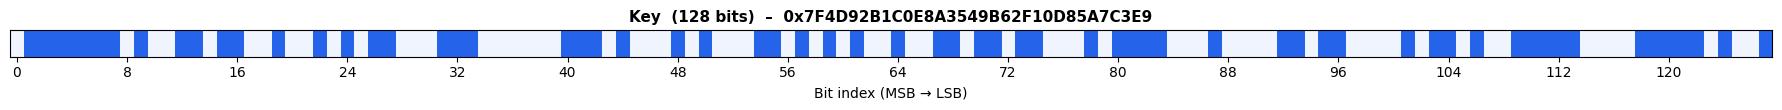

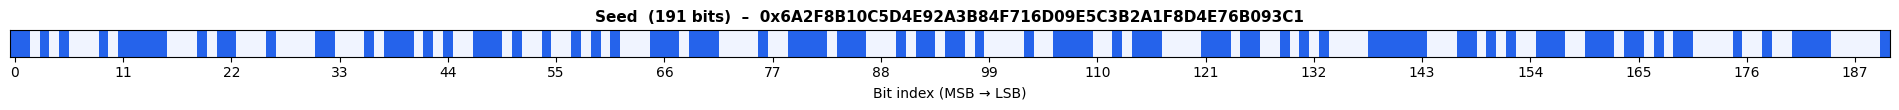

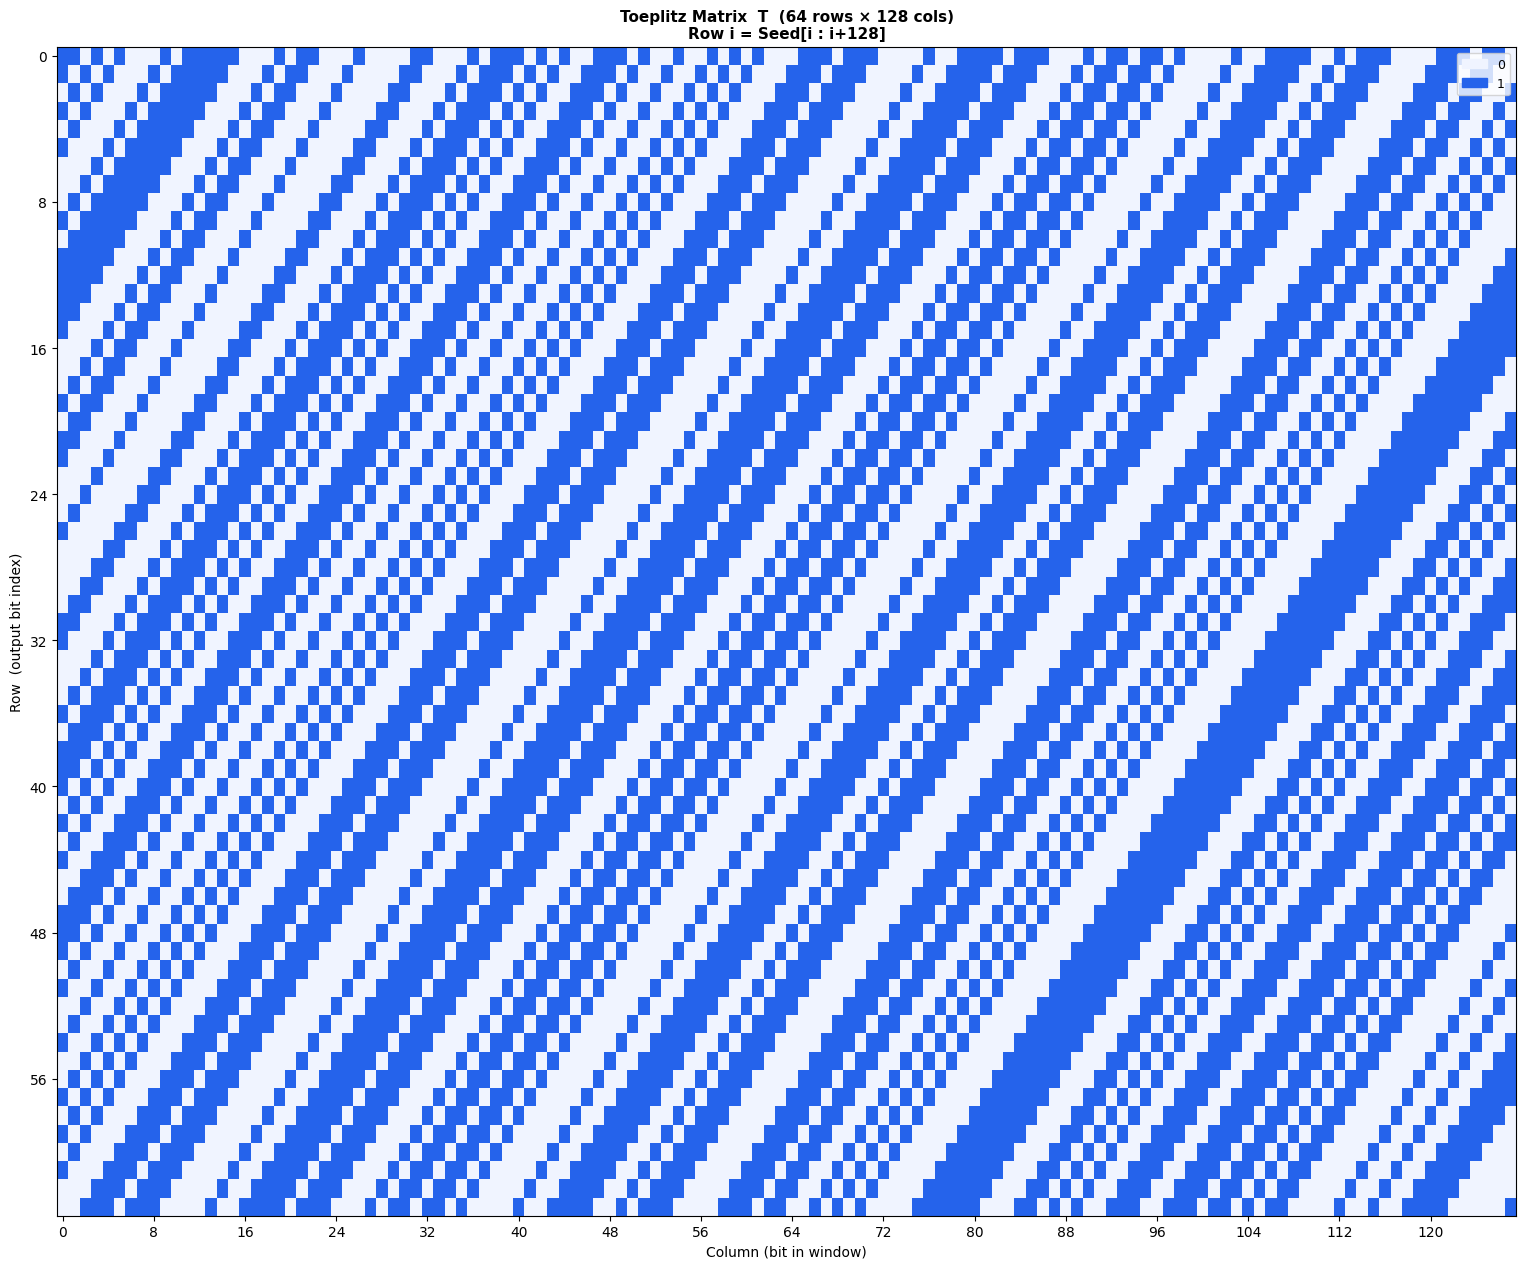

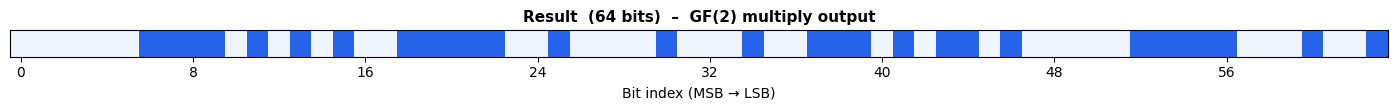

  OPERATION DETAIL  (first 0 and last 0 rows)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

# ─────────────────────────────────────────────
#  USER PARAMETERS
# ─────────────────────────────────────────────
N = 128   # Key length  (bits)
L = 64    # Output length (bits)
# Seed length = N + L - 1 = 191 bits

# ─────────────────────────────────────────────
#  HARDCODED KEY  (N bits → hex string)
# ─────────────────────────────────────────────
KEY_HEX = "7F4D92B1C0E8A3549B62F10D85A7C3E9"
key_hex_digits = (N + 3) // 4
KEY_HEX = KEY_HEX.zfill(key_hex_digits)[:key_hex_digits]

# ─────────────────────────────────────────────
#  HARDCODED SEED  (N+L-1 bits → hex string)
# ─────────────────────────────────────────────
SEED_LENGTH = N + L - 1   # 191 bits
SEED_HEX = "6A2F8B10C5D4E92A3B84F716D09E5C3B2A1F8D4E76B093C1"
seed_hex_digits = (SEED_LENGTH + 3) // 4
SEED_HEX = SEED_HEX.zfill(seed_hex_digits)[:seed_hex_digits]

# ─────────────────────────────────────────────
#  HEX ↔ BIT ARRAY helpers
# ─────────────────────────────────────────────
def hex_to_bits(hex_str, n_bits):
    value = int(hex_str, 16)
    return np.array([(value >> (n_bits - 1 - i)) & 1 for i in range(n_bits)], dtype=np.uint8)

def bits_to_hex(bits):
    n = len(bits)
    pad = (4 - n % 4) % 4
    padded = np.concatenate([np.zeros(pad, dtype=np.uint8), bits])
    hex_digits = len(padded) // 4
    value = int("".join(str(b) for b in padded), 2)
    return format(value, f"0{hex_digits}X")

# ─────────────────────────────────────────────
#  BUILD KEY & SEED BIT VECTORS
# ─────────────────────────────────────────────
key_bits  = hex_to_bits(KEY_HEX,  N)
seed_bits = hex_to_bits(SEED_HEX, SEED_LENGTH)

# ─────────────────────────────────────────────
#  BUILD TOEPLITZ MATRIX  shape (L, N)
#  Row i → Seed[i .. i+N-1]
# ─────────────────────────────────────────────
T = np.zeros((L, N), dtype=np.uint8)
for i in range(L):
    T[i, :] = seed_bits[i : i + N]

# ─────────────────────────────────────────────
#  GF(2) MATRIX–VECTOR MULTIPLY
#  result[i] = (T[i] · key) mod 2
# ─────────────────────────────────────────────
result_bits = np.mod(T @ key_bits, 2).astype(np.uint8)

# ═════════════════════════════════════════════
#  SUMMARY
# ═════════════════════════════════════════════
result_hex = bits_to_hex(result_bits)

print("=" * 72)
print("  HEX SUMMARY  ")
print("=" * 72)
print(f"  N            = {N}")
print(f"  L            = {L}")
print(f"  Seed length  = {SEED_LENGTH}")
print()
print(f"  KEY    (0x): {KEY_HEX}")
print()
seed_chunks = textwrap.wrap(SEED_HEX, 32)
print(f"  SEED   (0x): {seed_chunks[0]}")
for chunk in seed_chunks[1:]:
    print(f"               {chunk}")
print()
print(f"  RESULT (0x): {result_hex}")
print("=" * 72)

# ═════════════════════════════════════════════
#  VISUALISATION
# ═════════════════════════════════════════════
cmap = plt.cm.colors.ListedColormap(['#f0f4ff', '#2563eb']) if hasattr(plt.cm, 'colors') else None
try:
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#f0f4ff', '#2563eb'])
except Exception:
    cmap = 'Blues'

# ── 1. KEY vector ────────────────────────────
fig1, ax1 = plt.subplots(figsize=(min(N * 0.14, 20), 1.2))
ax1.imshow(key_bits[np.newaxis, :], cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax1.set_title(f'Key  ({N} bits)  –  0x{KEY_HEX}', fontsize=11, fontweight='bold')
ax1.set_xlabel('Bit index (MSB → LSB)')
ax1.set_yticks([])
ax1.set_xticks(range(0, N, max(1, N // 16)))
plt.tight_layout()
plt.show()

# ── 2. SEED vector ───────────────────────────
fig2, ax2 = plt.subplots(figsize=(min(SEED_LENGTH * 0.1, 22), 1.2))
ax2.imshow(seed_bits[np.newaxis, :], cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax2.set_title(f'Seed  ({SEED_LENGTH} bits)  –  0x{SEED_HEX}', fontsize=11, fontweight='bold')
ax2.set_xlabel('Bit index (MSB → LSB)')
ax2.set_yticks([])
ax2.set_xticks(range(0, SEED_LENGTH, max(1, SEED_LENGTH // 16)))
plt.tight_layout()
plt.show()

# ── 3. TOEPLITZ MATRIX ───────────────────────
fig3, ax3 = plt.subplots(figsize=(min(N * 0.12, 22), min(L * 0.2, 16)))
ax3.imshow(T, cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax3.set_title(f'Toeplitz Matrix  T  ({L} rows × {N} cols)\nRow i = Seed[i : i+{N}]',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Column (bit in window)')
ax3.set_ylabel('Row  (output bit index)')
ax3.set_xticks(range(0, N, max(1, N // 16)))
ax3.set_yticks(range(0, L, max(1, L // 8)))
p0 = mpatches.Patch(color='#f0f4ff', label='0')
p1 = mpatches.Patch(color='#2563eb', label='1')
ax3.legend(handles=[p0, p1], loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# ── 4. RESULT vector ─────────────────────────
fig4, ax4 = plt.subplots(figsize=(min(L * 0.22, 18), 1.2))
ax4.imshow(result_bits[np.newaxis, :], cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax4.set_title(f'Result  ({L} bits)  –  GF(2) multiply output', fontsize=11, fontweight='bold')
ax4.set_xlabel('Bit index (MSB → LSB)')
ax4.set_yticks([])
ax4.set_xticks(range(0, L, max(1, L // 8)))
plt.tight_layout()
plt.show()

# ═════════════════════════════════════════════
#  FIRST / LAST ROW VALIDATION
# ═════════════════════════════════════════════
SHOW = 0

print("=" * 72)
print(f"  OPERATION DETAIL  (first {SHOW} and last {SHOW} rows)")
print("=" * 72)

rows_to_show = list(range(SHOW)) + list(range(L - SHOW, L))
for i in rows_to_show:
    if i == SHOW:
        print(f"  ... ({L - 2*SHOW} rows omitted) ...")
    row_hex = bits_to_hex(T[i])
    dot     = int(np.dot(T[i].astype(int), key_bits.astype(int)))
    mod2    = dot % 2
    print(f"  Row {i:3d} │ Seed[{i}:{i+N}]")
    print(f"         │ row_hex = 0x{row_hex}")
    print(f"         │ dot(row, key) = {dot:4d}  →  mod 2 = {mod2}   [result bit = {result_bits[i]}]")
    print()